In [8]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import KFold
print("RAN")

RAN


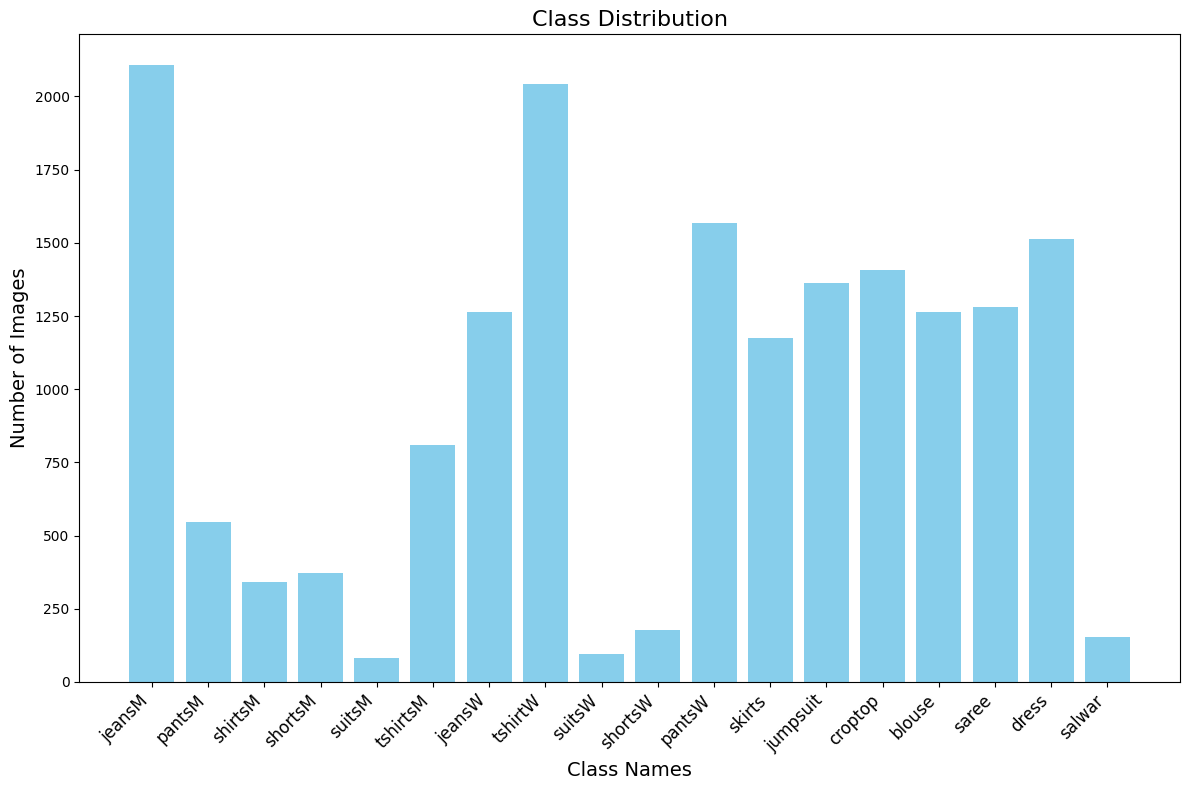

In [9]:
import os
from PIL import Image
import matplotlib.pyplot as plt

# Verify dataset path
dataset_path = "/kaggle/input/clothing-identification-cnn/ModdeDataset"

# MALE DATA
male_classes = {
    "jeansM": dataset_path + "/jeansM",
    "pantsM": dataset_path + "/pantsM",
    "shirtsM": dataset_path + "/shirtsM",
    "shortsM": dataset_path + "/shortsM",
    "suitsM": dataset_path + "/suitsM",
    "tshirtsM": dataset_path + "/tshirtsM"
}

# FEMALE DATA
female_classes = {
    "jeansW": dataset_path + "/jeansW",
    "tshirtW": dataset_path + "/tshirtW",
    "suitsW": dataset_path + "/suitsW",
    "shortsW": dataset_path + "/shortsW",
    "pantsW": dataset_path + "/pantsW",
    "skirts": dataset_path + "/skirt",
    "jumpsuit": dataset_path + "/jumpsuit",
    "croptop": dataset_path + "/croptop",
    "blouse": dataset_path + "/blouse",
    "saree": dataset_path + "/Saree",
    "dress": dataset_path + "/dress",
    "salwar": dataset_path + "/salwar"
}

# Combine all classes
classes = {**male_classes, **female_classes}

# Output path for converted images
jpeg_dataset_path = "/kaggle/working/MODDE_JPEG"

# Function to convert images to JPEG format
def convert_images_to_jpeg(src_dir, dest_dir):
    if not os.path.exists(dest_dir):
        os.makedirs(dest_dir)

    for root, _, files in os.walk(src_dir):
        for file in files:
            src_file_path = os.path.join(root, file)
            dest_file_path = os.path.join(dest_dir, os.path.relpath(root, src_dir), file)
            dest_file_dir = os.path.dirname(dest_file_path)

            if not os.path.exists(dest_file_dir):
                os.makedirs(dest_file_dir)

            file_extension = os.path.splitext(file)[1].lower()

            # Skip if the file already exists in the destination directory
            if os.path.exists(dest_file_path):
                continue

            try:
                with Image.open(src_file_path) as img:
                    if img.mode != 'RGB':
                        img = img.convert('RGB')
                    dest_file_path = os.path.splitext(dest_file_path)[0] + '.jpg'
                    img.save(dest_file_path, 'JPEG')
            except Exception as e:
                print(f"Failed to process {src_file_path}: {e}")

# Convert images to JPEG format
convert_images_to_jpeg(dataset_path, jpeg_dataset_path)

# Updated classes dictionary for the JPEG dataset
jpeg_classes = {class_name: jpeg_dataset_path + '/' + os.path.basename(class_dir) for class_name, class_dir in classes.items()}

# Count the number of images in each class
class_counts = {}
for class_name, class_dir in jpeg_classes.items():
    if os.path.exists(class_dir):  # Ensure the directory exists
        class_counts[class_name] = len([file for file in os.listdir(class_dir) if file.lower().endswith('.jpg')])
    else:
        class_counts[class_name] = 0

# Plot the class distribution
plt.figure(figsize=(12, 8))
plt.bar(class_counts.keys(), class_counts.values(), color='skyblue')
plt.xlabel('Class Names', fontsize=14)
plt.ylabel('Number of Images', fontsize=14)
plt.title('Class Distribution', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
# Load training and validation datasets
batch_size = 32
img_size = (256, 256)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    jpeg_dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    jpeg_dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)



# Check the class names
class_names = train_ds.class_names
print("Class names:", class_names)

# Apply normalization
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))


# Define data augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    #tf.keras.layers.RandomZoom(height_factor=(-0.2, -0.3), width_factor=(-0.2, -0.3)),
    #tf.keras.layers.RandomContrast(factor=0.1),
    #tf.keras.layers.GaussianNoise(0.1),  # Adds Gaussian noise to the input
    #tf.keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
])

#Display first 9 images from the normalized & augmented dataset
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(25):
        ax = plt.subplot(5, 5, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")
        1
plt.show()


In [ ]:
# Define the CNN architecture
def create_cnn_model(input_shape, num_classes):
    model = tf.keras.models.Sequential([  
        
         # Block 1
        tf.keras.layers.Conv2D(16, (3, 3), activation='relu', input_shape=input_shape),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),

        # Block 2
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.4),
        
        # Flatten and Dense
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.5),

        tf.keras.layers.Dense(num_classes, activation='softmax')
        
    ])
    model.summary()
    return model

input_shape = (256, 256, 3)
num_classes = len(class_names)

cnn_model = create_cnn_model(input_shape, num_classes)

# Compile the model
cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Print a message indicating the model is compiled
print("Model compiled successfully.")

# Implement early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

# Apply data augmentation during training
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

# Train the model
history = cnn_model.fit(train_ds,
                        validation_data=val_ds,
                        epochs=1,# <-- CHANGE THE number of epochs here to tune to avoid OVERFITTING 
                        callbacks=[early_stopping])

# Evaluate the model
val_loss, val_accuracy = cnn_model.evaluate(val_ds)
print(f'Validation accuracy: {val_accuracy:.2f}')
print(f'Validation loss: {val_loss:.2f}')


In [ ]:
'''
       # Third block: even deeper with dilated convolution for capturing more context
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu', dilation_rate=(2, 2)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Dropout(0.4),

        # Fourth block: wide features with larger kernel size
        tf.keras.layers.Conv2D(256, (7, 7), activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Dropout(0.4),'''

In [ ]:
# Visualize training history
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='training loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='training accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Save the model
cnn_model.save('/kaggle/working/cnn_model.keras')

# Load model
loaded_model = tf.keras.models.load_model('/kaggle/working/cnn_model.keras')

In [ ]:
# Save the model
cnn_model.save('/kaggle/working/cnn_model.keras')

# Load model
loaded_model = tf.keras.models.load_model('/kaggle/working/cnn_model.keras')